:::{admonition} Download
:class: important

Download this notebook: **{nb-download}`quickstart.ipynb`**!

:::


# Quickstart

## **Overview**

NeMoS is a neural modeling software package designed to model neural spiking activity and other time-series data
 powered by [JAX](https://jax.readthedocs.io/en/latest/).

At its core, NeMoS consists of two primary modules: the **`glm`** and the **`basis`** module:

The **`glm`** module implements a Generalized Linear Model (GLM) to map features to neural activity, such as
spike counts or calcium transients. It supports learning GLM weights, evaluating model performance, and exploring
model behavior on new inputs.


The **`basis`** module focuses on designing model features (inputs) for the GLM.
It includes a suite of composable feature constructors that accept time-series data, allowing users to model a wide
range of observed variables—such as stimuli, head direction, position, or spike counts— as inputs to the GLM.


## **Generalized Linear Model**

NeMoS provides two implementations of the GLM: one for fitting a single neuron, and one for fitting a  neural population simultaneously.

### **Single Neuron GLM**

You can define a single neuron GLM by instantiating an `GLM` object.

In [1]:
import nemos as nmo

# Instantiate the single model
model = nmo.glm.GLM()


The coefficients can be learned by invoking the `fit` method of `GLM`. The method requires a design
matrix of shape `(num_samples, num_features)`, and the output neural activity of shape `(num_samples, )`.

In [2]:
import numpy as np
num_samples, num_features = 100, 3

# Generate a design matrix
X = np.random.normal(size=(num_samples, num_features))
# generate some counts
spike_counts = np.random.poisson(size=num_samples)

# define fit the model
model = model.fit(X, spike_counts)


Once the model is fit, you can retrieve the model parameters as shown below.

In [3]:
# model coefficients shape is (num_features, )
print(f"Model coefficients shape: {model.coef_.shape}")

# model intercept, shape (1,) since there is only one neuron.
print(f"Model intercept shape: {model.intercept_.shape}")


Model coefficients shape: (3,)
Model intercept shape: (1,)


Additionally, you can predict the firing rate and call the compute the model log-likelihood by calling the `predict` and the `score` method respectively.

In [4]:
# predict the rate
predicted_rate = model.predict(X)
# firing rate has shape: (num_samples,)
predicted_rate.shape


# compute the log-likelihood of the model
log_likelihood = model.score(X, spike_counts)


### **Population GLM**

You can set up a population GLM by instantiating a `PopulationGLM`. The API for the `PopulationGLM` is the same as for the single-neuron `GLM`; the only difference you'll notice is that some of the methods' inputs and outputs have an additional dimension for the different neurons.

In [5]:
import nemos as nmo
population_model = nmo.glm.PopulationGLM()


As for the single neuron GLM, you can learn the model parameters by invoking the `fit` method: the input of `fit` are the design matrix (with shape `(num_samples, num_features)` ), and the population activity (with shape `(num_samples, num_neurons)`).
Once the model is fit, you can use `predict` and `score` to predict the firing rate and the log-likelihood.

In [6]:
import numpy as np
num_samples, num_features, num_neurons = 100, 3, 5

# simulate a design matrix
X = np.random.normal(size=(num_samples, num_features))
# simulate some counts
spike_counts = np.random.poisson(size=(num_samples, num_neurons))

# fit the model
population_model = population_model.fit(X, spike_counts)

# predict the rate of each neuron in the population
predicted_rate = population_model.predict(X)
predicted_rate.shape  # expected shape: (num_samples, num_neurons)


# compute the log-likelihood of the model
log_likelihood = population_model.score(X, spike_counts)


The learned coefficient and intercept will have shape `(num_features, num_neurons)` and `(num_neurons, )` respectively.

In [7]:
# model coefficients shape is (num_features, num_neurons)
print(f"Model coefficients shape: {population_model.coef_.shape}")

# model intercept, (num_neurons,)
print(f"Model intercept shape: {population_model.intercept_.shape}")


Model coefficients shape: (3, 5)
Model intercept shape: (5,)


### **Classifier GLM**

For classification tasks, such as modeling behavioral choices, NeMoS provides the `ClassifierGLM`. This model treats observations as categorical random variables.

In [8]:
import nemos as nmo

# Instantiate a categorical model for 3 categories
n_classes = 3
model = nmo.glm.ClassifierGLM(n_classes)


The [`ClassifierGLM`](nemos.glm.ClassifierGLM) follows a similar API to the standard GLM, with a few key differences:

- [`predict`](nemos.glm.ClassifierGLM.predict) returns predicted category labels (unlike the standard `GLM` model, which returns predicted firing rates).
- [`predict_proba`](nemos.glm.ClassifierGLM.predict_proba) returns the probability of each category.
- The `observation_model` parameter cannot be set at model initialization, since [`CategoricalObservations`](nemos.observation_models.CategoricalObservations) is the only compatible observation model.

In [9]:
import numpy as np
num_samples, num_features = 100, 3

# Generate a design matrix
X = np.random.normal(size=(num_samples, num_features))
# simulate categorical observations (values 0, 1, or 2)
choices = np.random.choice(n_classes, size=num_samples)

# fit the model
model = model.fit(X, choices)

# predict categories
predicted_categories = model.predict(X)

# get probability for each category
probabilities = model.predict_proba(X)
probabilities.shape  # expected shape: (num_samples, n_classes)


(100, 3)

For fitting multiple subjects in parallel, use `ClassifierPopulationGLM`:

In [10]:
# fit multiple subjects simultaneously
population_model = nmo.glm.ClassifierPopulationGLM(n_classes)


For a complete example with confusion matrix visualization, see the [GLM for Classification how-to guide](how_to_guide/glm_for_classification).

## **Basis: Feature Construction**

The `basis` module includes objects that perform two types of transformations on the inputs:

1. **Non-linear Mapping:** This process transforms the input data through a non-linear function,
   allowing it to capture complex, non-linear relationships between inputs and neuronal firing rates.
   Importantly, this transformation preserves the properties that makes GLM easy to fit and guarantee a
   single optimal solution (e.g. convexity).

2. **Convolution:** This applies a convolution of the input data with a bank of filters, designed to
   capture linear temporal effects. This transformation is particularly useful when analyzing data with
   inherent time dependencies or when the temporal dynamics of the input are significant.
    Both transformations produce a vector of features `X` that changes over time, with a shape
    of `(n_time_points, n_features)`.

### **Non-linear Mapping**

<figure class="custom-figure">
    <img src="_static/glm_features_scheme.svg" alt="GLM Feature Scheme" width="100%">
    <figcaption><strong>Figure 1:</strong> Basis as non-linear mappings. The figure demonstrate the use of basis functions to create complex non-linear features for a GLM.</figcaption>
</figure>

Non-linear mapping is the default mode of operation of any `basis` object. To instantiate a basis for non-linear mapping,
you need to specify the number of basis functions. For some `basis` objects, additional arguments may be required (see the [API Reference](nemos_basis) for detailed information).

In [11]:
import nemos as nmo

n_basis_funcs = 10
basis = nmo.basis.RaisedCosineLinearEval(n_basis_funcs)


Once the basis is instantiated, you can apply it to your input data using the `compute_features` method.
This method takes an input array of shape `(n_samples, )` and transforms it into a two-dimensional array of
shape `(n_samples, n_basis_funcs)`, where each column represents a feature generated by the non-linear mapping.

In [12]:
import numpy as np

# generate an input
x = np.arange(100)

# evaluate the basis
X = basis.compute_features(x)
X.shape


(100, 10)

### **Convolution**

<figure class="custom-figure">
    <img src="_static/glm_population_scheme.svg" alt="GLM Population Scheme">
    <figcaption><strong>Figure 2:</strong> Basis as a bank of convolutional filters. The figure shows a population GLM for functional connectivity analysis, a classical use-case for basis functions in convolutional mode.</figcaption>

</figure>

If you want to convolve a bank of basis functions with an input you must set the mode of operation of a basis object to
`"conv"` and you must provide an integer `window_size` parameter, which defines the length of the filter bank in
number of sample points.

In [13]:
import nemos as nmo

n_basis_funcs = 10
# define a filter bank of 10 basis function, 200 samples long.
basis = nmo.basis.BSplineConv(n_basis_funcs, window_size=200)


Once the basis is initialized, you can call `compute_features` on an input of shape `(n_samples, )` or
`(n_samples, n_signals)` to perform the convolution. The output will be a 2-dimensional array of shape
`(n_samples, n_basis_funcs)` or `(n_samples, n_basis_funcs * n_signals)` respectively.

:::{admonition} Signal length and window size
:class: warning

The `window_size` must be shorter than the number of samples in the signal(s) being convolved.
:::

In [14]:
import numpy as np

x = np.ones(500)

# convolve a single signal
X = basis.compute_features(x)
X.shape

x_multi = np.ones((500, 3))

# convolve a multiple signals
X_multi = basis.compute_features(x_multi)
X_multi.shape


(500, 30)

For additional information on one-dimensional convolutions, see [here](convolution_background).


## **Other Observation Models**

### **Continuous Observations**

By default, NeMoS' GLM uses [Poisson observations](nemos.observation_models.PoissonObservations), which are a natural choice for spike counts. However, the
package also supports a [Gamma](nemos.observation_models.GammaObservations) GLM and a [Gaussian](nemos.observation_models.GaussianObservations) GLM.

#### Gamma Observations

The Gamma observation model is more appropriate for modeling continuous, non-negative observations such as calcium transients.

To change the default observation model, set the `observation_model` argument during initialization:

In [15]:
import nemos as nmo

# set up a Gamma GLM for modeling continuous non-negative data
glm = nmo.glm.GLM(observation_model=nmo.observation_models.GammaObservations())


#### Gaussian Observations

The Gaussian observation model is suitable for modeling continuous data that can take on both positive and negative values.

In [16]:
import nemos as nmo

# set up a Gaussian GLM for modeling continuous data
glm = nmo.glm.GLM(observation_model="Gaussian")


Take a look at our [tutorial](tutorial-calcium-imaging) for a detailed example.

### **Binary Observations**


NeMoS additionally supports a [Bernoulli observation model](nemos.observation_models.BernoulliObservations), which is useful for modeling binary observations, such as a binary choices or singular spikes. To use this observation model, set the `observation_model` argument during model initialization.

In [17]:
import nemos as nmo

# set up a Bernoulli GLM for modeling binary observations
glm = nmo.glm.GLM(observation_model=nmo.observation_models.BernoulliObservations())


### **Counts with Supra-Poisson Variability**

A [Negative Binomial observation model](nemos.observation_models.NegativeBinomialObservations) is appropriate for describing a counting process (such as neural spike counts) that exhibits supra-Poisson variability — that is, it is over-dispersed relative to a Poisson model (equivalently, the variance of the counts is larger than the mean).

To set up a Negative Binomial GLM, provide this `observation_model` at initialization. The degree of overdispersion can be controlled via the `scale` parameter: larger values of `scale` result in greater variability compared to a Poisson model, while as `scale` approaches zero, the distribution converges to a Poisson. An appropriate value for `scale` depends on the distribution of the observed spike counts and should be tuned, for example through [cross-validation](sklearn-how-to).

In [18]:
import nemos as nmo

# set up a Negative Binomial GLM for modeling counts (with scale = 1)
glm = nmo.glm.GLM(observation_model=nmo.observation_models.NegativeBinomialObservations(scale=1))


## **Regularization**


NeMoS supports various regularization schemes, including [Ridge](nemos.regularizer.Ridge) ($L_2$), [Lasso](nemos.regularizer.Lasso) ($L_1$), [ElasticNet](nemos.regularizer.ElasticNet) ($L_1 + L_2$), and [Group Lasso](nemos.regularizer.GroupLasso), to prevent overfitting and improve model generalization.

You can specify the regularization scheme and its strength when initializing the GLM model:

In [19]:
import nemos as nmo

# Instantiate a GLM with Ridge (L2) regularization
glm = nmo.glm.GLM(regularizer="Ridge", regularizer_strength=0.1)


For [ElasticNet](nemos.regularizer.ElasticNet) regularization, you can also set a regularizer ratio, specifying the balance between $L_1$ and $L_2$ regularization, where a ratio of 1 is equivalent to $L_1$ (Lasso) and a value of 0 is equivalent to $L_2$ (Ridge). This can be set by passing a tuple of values to `regularizer_strength`, where the first value is the strength and the second is the ratio.

In [20]:
# set regularizer strength to 0.1 and regularizer ratio to 0.5
glm = nmo.glm.GLM(regularizer="ElasticNet", regularizer_strength=(0.1,0.5))


## **Pre-processing with `pynapple`**


:::{note}

This section assumes some familiarity with the `pynapple` package for time series manipulation and data
exploration. If you'd like to learn more about it, take a look at the [`pynapple` documentation](https://pynapple-org.github.io/pynapple/).
:::

`pynapple` is an extremely helpful tool when working with time series data. You can easily perform operations such
as restricting your time series to specific epochs (sleep/wake, context A vs. context B, etc.), as well as common
pre-processing steps in a robust and efficient manner. This includes bin-averaging, counting, convolving, smoothing and many
others. All these operations can be easily concatenated for a quick and easy data pre-processing.

In NeMoS, if a transformation  preserve the time axis and you use a `pynapple` time series as input, the result will
also be a `pynapple` time series.

A canonical example of this behavior is the `predict` method of `GLM`.

In [21]:
import numpy as np
import pynapple as nap

# suppress jax to numpy conversion warning
nap.nap_config.suppress_conversion_warnings = True

# create a TsdFrame with the features and a Tsd with the counts
X = nap.TsdFrame(t=np.arange(100), d=np.random.normal(size=(100, 2)))
y = nap.Tsd(t=np.arange(100), d=np.random.poisson(size=(100, )))

print(type(X))  # shape (num samples, num features)

model = nmo.glm.GLM()
model = model.fit(X, y)  # the following works

firing_rate = model.predict(X)  # predict the firing rate of the neuron

# this will still be a pynapple time series
print(type(firing_rate))  # shape (num_samples, )


<class 'pynapple.core.time_series.TsdFrame'>


<class 'pynapple.core.time_series.Tsd'>


Let's see how you can greatly streamline your analysis pipeline by integrating `pynapple` and NeMoS.


:::{note}

You can download this dataset by clicking [here](https://www.dropbox.com/s/su4oaje57g3kit9/A2929-200711.zip?dl=1).
:::

In [22]:
import nemos as nmo
import pynapple as nap

path = nmo.fetch.fetch_data("A2929-200711.nwb")
data = nap.load_file(path)

# load spikes and head direction
spikes = data["units"]
head_dir = data["ry"]

# restrict and bin
counts = spikes[6].count(0.01, ep=head_dir.time_support)

# down-sample head direction
upsampled_head_dir = head_dir.bin_average(0.01)

# create your features
X = nmo.basis.CyclicBSplineEval(10).compute_features(upsampled_head_dir)

# add a neuron axis and fit model
model = nmo.glm.GLM().fit(X, counts)


  0%|                                              | 0.00/7.13M [00:00<?, ?B/s]

Finally, let's compare the tuning curves

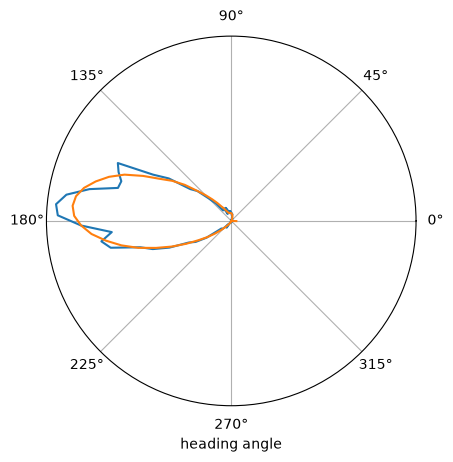

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# tuning curves
raw_tuning = nap.compute_tuning_curves(spikes, head_dir, bins=100, feature_names=["angles"])
raw_tuning = raw_tuning.sel(unit=6)

# model based tuning curve
model_tuning = nap.compute_tuning_curves(
    model.predict(X)[:, np.newaxis] * X.rate,  # scale by the sampling rate
    head_dir,
    bins=100,
    feature_names=["angles"]
 ).sel(unit=0)


# plot results
sub = plt.subplot(111, projection="polar")
plt1 = plt.plot(raw_tuning.angles, raw_tuning, label="raw")
plt2 = plt.plot(model_tuning.angles, model_tuning, label="glm")
legend = plt.yticks([])
xlab = plt.xlabel("heading angle")


## **Compatibility with `scikit-learn`**


[`scikit-learn`](https://scikit-learn.org/stable/) is a machine learning toolkit that offers advanced features like pipelines and cross-validation methods.
NeMoS takes advantage of these features, while still gaining the benefit of JAX's just-in-time compilation and GPU-acceleration!

For example, if we would like to tune the critical hyper-parameter `regularizer_strength`, we  could easily run a `K-Fold` cross-validation[^1] using `scikit-learn`.

[^1]: For a detailed explanation and practical examples, refer to the [cross-validation page](https://scikit-learn.org/stable/modules/cross_validation.html) in the `scikit-learn` documentation.

In [24]:
# set up the model
import nemos as nmo
import numpy as np

# generate data
X, counts = np.random.normal(size=(100, 3)), np.random.poisson(size=100)

# model definition
model = nmo.glm.GLM(regularizer="Ridge", regularizer_strength=0.1)


Fit a 5-fold cross-validation scheme for comparing two different regularizer strengths:

In [25]:
from sklearn.model_selection import GridSearchCV

# define the parameter grid
param_grid = dict(regularizer_strength=(0.01, 0.001))

# define the 5-fold cross-validation grid search from sklearn
cls = GridSearchCV(model, param_grid=param_grid, cv=5)

# run the 5-fold cross-validation grid search
cls = cls.fit(X, counts)


:::{admonition} Cross-Validation in NeMoS
:class: info

For more information and a practical example on how to construct a parameter grid and cross-validate hyperparameters across an entire pipeline, please refer to the [tutorial on pipelining and cross-validation](sklearn-how-to).
:::

Finally, we can print the regularizer strength with the best cross-validated performance:

In [26]:
# print best regularizer strength
print(cls.best_params_)


{'regularizer_strength': 0.01}


Enjoy modeling with NeMoS!